# 04 — Train Model (Transfer Learning)

ใช้ **MobileNetV2** pretrained บน ImageNet มาเทรน classifier สำหรับแยก `cos` และ `gok`

กลยุทธ์:
1. Freeze backbone ทั้งหมด — เทรนเฉพาะ classifier head
2. บันทึก best model ตาม val accuracy
3. Plot learning curve

## 1. Import และตั้งค่า Device

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'ใช้ device: {device}')

ใช้ device: cuda


## 2. DataLoader (นำจาก 03)

In [2]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
DATA_DIR   = 'data'
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

train_dataset = ImageFolder(f'{DATA_DIR}/train', transform=train_transforms)
val_dataset   = ImageFolder(f'{DATA_DIR}/val',   transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f'class mapping: {train_dataset.class_to_idx}')
print(f'train: {len(train_dataset)} ภาพ | val: {len(val_dataset)} ภาพ')

class mapping: {'cos': 0, 'gok': 1}
train: 2044 ภาพ | val: 408 ภาพ


## 3. สร้างโมเดล

In [3]:
class CosGokClassifier(nn.Module):
    def __init__(self, num_classes=2, size_inner=128, droprate=0.2):
        super().__init__()
        backbone = models.mobilenet_v2(weights='IMAGENET1K_V1')

        # Freeze backbone ทั้งหมด — เทรนเฉพาะ head ก่อน
        for param in backbone.parameters():
            param.requires_grad = False

        self.features = backbone.features
        self.pool     = nn.AdaptiveAvgPool2d((1, 1))
        self.head     = nn.Sequential(
            nn.Linear(1280, size_inner),
            nn.ReLU(),
            nn.Dropout(droprate),
            nn.Linear(size_inner, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.head(x)


model = CosGokClassifier().to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'trainable params: {trainable:,} / {total:,}')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\kbbos/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:03<00:00, 4.70MB/s]


trainable params: 164,226 / 2,388,098


## 4. Training Loop

In [4]:
NUM_EPOCHS = 10
LR         = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc  = 0.0
best_model_path = 'best_model.pth'

for epoch in range(NUM_EPOCHS):
    # --- Train ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc  = correct / total

    # --- Validate ---
    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss_sum += criterion(outputs, labels).item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    val_loss = val_loss_sum / len(val_loader)
    val_acc  = val_correct / val_total

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        saved_mark = ' ← saved'
    else:
        saved_mark = ''

    print(f'Epoch {epoch+1:02d}/{NUM_EPOCHS} | '
          f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
          f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}{saved_mark}')

print(f'\nbest val_acc: {best_val_acc:.4f} → {best_model_path}')

Epoch 01/10 | train_loss=0.1347 train_acc=0.9501 | val_loss=0.0329 val_acc=0.9902 ← saved
Epoch 02/10 | train_loss=0.0284 train_acc=0.9917 | val_loss=0.0103 val_acc=1.0000 ← saved
Epoch 03/10 | train_loss=0.0170 train_acc=0.9961 | val_loss=0.0100 val_acc=0.9975
Epoch 04/10 | train_loss=0.1201 train_acc=0.9604 | val_loss=0.0393 val_acc=0.9804
Epoch 05/10 | train_loss=0.0215 train_acc=0.9897 | val_loss=0.0059 val_acc=1.0000
Epoch 06/10 | train_loss=0.0108 train_acc=0.9961 | val_loss=0.0104 val_acc=0.9951
Epoch 07/10 | train_loss=0.0234 train_acc=0.9922 | val_loss=0.0181 val_acc=0.9926
Epoch 08/10 | train_loss=0.0245 train_acc=0.9897 | val_loss=0.0321 val_acc=0.9877
Epoch 09/10 | train_loss=0.0106 train_acc=0.9961 | val_loss=0.0061 val_acc=0.9975
Epoch 10/10 | train_loss=0.0150 train_acc=0.9941 | val_loss=0.0399 val_acc=0.9853

best val_acc: 1.0000 → best_model.pth


## 5. Learning Curve

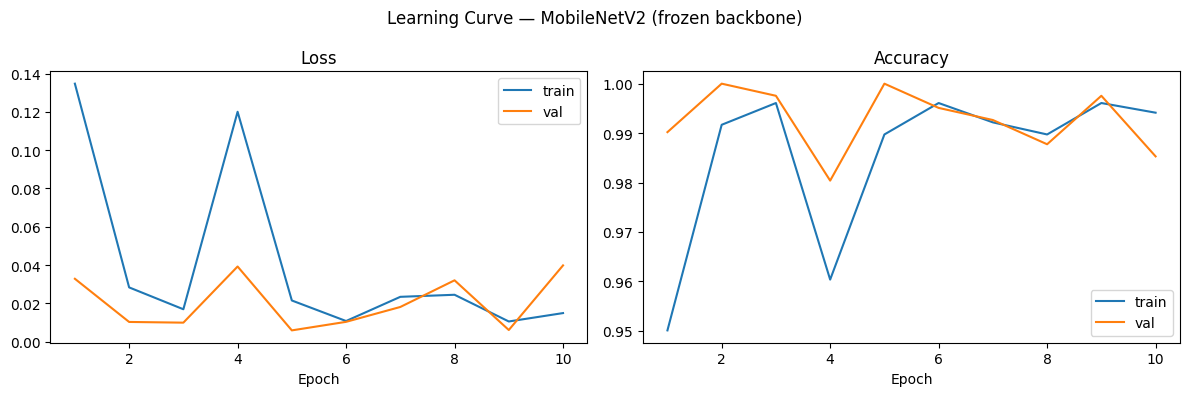

In [5]:
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history['train_loss'], label='train')
ax1.plot(epochs, history['val_loss'],   label='val')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(epochs, history['train_acc'], label='train')
ax2.plot(epochs, history['val_acc'],   label='val')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.suptitle('Learning Curve — MobileNetV2 (frozen backbone)')
plt.tight_layout()
plt.show()